In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data10.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data11.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data12.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data8.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data13.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data7.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data5.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data15.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data9.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data14.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data6.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data4.csv
/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data2.csv
/kaggle/input/power-system/binaryAllNaturalPl

![](https://occupy.com/sites/default/files/medialibrary/Microgrid-The-Post-Microgrid-Distribution-System-1.gif)

# About Dataset

> *Power System Attack Datasets - Mississippi State University and Oak Ridge National Laboratory - 4/15/2014.
There are three datasets contained in this folder. They are made from one initial dataset consisting of fifteen sets with 37 power system event scenarios in each. The multiclass datasets are in ARFF format for easy use with Weka and the others are in CSV format also compatible with Weka. The 37 scenarios are divided into Natural Events (8), No Events (1) and Attack Events (28). The datasets were randomly sampled at one percent and grouped into:*

> - Binary
> - Three-class and
> - Multiclass datasets.

> **The figure below shows the power system framework configuration used in generating these scenarios. In the network diagram we have several components; firstly, G1 and G2 are power generators. R1 through R4 are Intelligent Electronic Devices (IEDs) that can switch the breakers on or off. These breakers are labeled BR1 through BR4. We also have two lines. Line One spans from breaker one (BR1) to breaker two (BR2) and Line Two spans from breaker three (BR3) to breaker four (BR4). Each IED automatically controls one breaker. R1 controls BR1, R2 controls BR2 and son on accordingly. The IEDs use a distance protection scheme which trips the breaker on detected faults whether actually valid or faked since they have no internal validation to detect the difference. Operators can also manually issue commands to the IEDs R1 through R4 to manually trip the breakers BR1 through BR4. The manual override is used when performing maintenance on the lines or other system components.**

## *Types of Scenarios:*
1. Short-circuit fault – this is a short in a power line and can occur in various locations along the line, the location is indicated by the percentage range.
2. Line maintenance –one or more relays are disabled on a specific line to do maintenance for that line.
3. Remote tripping command injection (Attack) – this is an attack that sends a command to a relay which causes a breaker to open. It can only be done once an attacker has penetrated outside defenses.
4. Relay setting change (Attack) – relays are configured with a distance protection scheme and the attacker changes the setting to disable the relay function such that relay will not trip for a valid fault or a valid command.
5. Data Injection (Attack) – here we imitate a valid fault by changing values to parameters such as current, voltage, sequence components etc. This attack aims to blind the operator and causes a black out.

> **The 128 features are explained in the table below. There are 29 types of measurements from each phasor measurement units (PMU). A phasor measurement unit (PMU) or synchrophasor is a device which measures the electrical waves on an electricity grid, using a common time source for synchronization. In our system there are 4 PMUs which measure 29 features for 116 PMU measurement columns total. The index of each column is in the form of “R#-Signal Reference” that indicates a type of measurement from a PMU specified by “R#”. The signal references and corresponding descriptions are listed below. For example, R1-PA1:VH means Phase A voltage phase angle measured by PMU R1. After the PMU measurement columns, there are 12 columns for control panel logs, Snort alerts and relay logs of the 4 PMU/relay (relay and PMU are integrated together). The last column is the marker. The first three digits on the right is the load condition (in Megawatt). Another three digits to their left is fault locations, for example, “085” means fault at 85% of the transmission line specified by scenario description. However, for those that do not involve fault, e.g. “line maintenance”, these digits will be set to 000. The most left one digit or two digits indicate(s) the scenario number.**

In [2]:
import pandas as pd  
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

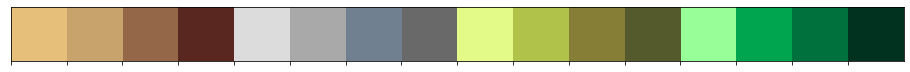

In [4]:
colors = [
    "#e6bf7b", "#c8a36c", "#936747", "#592720", "#dcdcdc", "#a9a9a9",
    "#708090", "#696969", "#e3f988", "#b0c24a", "#867e36", "#545a2c",
    "#98ff98", "#00a550", "#00703c", "#013220"
]
sns.palplot(sns.color_palette(colors))

In [5]:
df= pd.read_csv('/kaggle/input/power-system/binaryAllNaturalPlusNormalVsAttacks/data1.csv')

In [6]:
df =df[~df.isin([np.nan, np.inf, -np.inf]).any(1)]
df.head()

,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH,R1-PM3:V,R1-PA4:IH,R1-PM4:I,R1-PA5:IH,R1-PM5:I,R1-PA6:IH,R1-PM6:I,R1-PA7:VH,R1-PM7:V,R1-PA8:VH,R1-PM8:V,R1-PA9:VH,R1-PM9:V,R1-PA10:IH,R1-PM10:I,R1-PA11:IH,R1-PM11:I,R1-PA12:IH,R1-PM12:I,R1:F,R1:DF,R1-PA:Z,R1-PA:ZH,R1:S,R2-PA1:VH,R2-PM1:V,R2-PA2:VH,R2-PM2:V,R2-PA3:VH,R2-PM3:V,R2-PA4:IH,R2-PM4:I,R2-PA5:IH,R2-PM5:I,R2-PA6:IH,R2-PM6:I,R2-PA7:VH,R2-PM7:V,R2-PA8:VH,R2-PM8:V,R2-PA9:VH,R2-PM9:V,R2-PA10:IH,R2-PM10:I,R2-PA11:IH,R2-PM11:I,R2-PA12:IH,R2-PM12:I,R2:F,R2:DF,R2-PA:Z,R2-PA:ZH,R2:S,R3-PA1:VH,R3-PM1:V,R3-PA2:VH,R3-PM2:V,R3-PA3:VH,R3-PM3:V,R3-PA4:IH,R3-PM4:I,R3-PA5:IH,R3-PM5:I,R3-PA6:IH,R3-PM6:I,R3-PA7:VH,R3-PM7:V,R3-PA8:VH,R3-PM8:V,R3-PA9:VH,R3-PM9:V,R3-PA10:IH,R3-PM10:I,R3-PA11:IH,R3-PM11:I,R3-PA12:IH,R3-PM12:I,R3:F,R3:DF,R3-PA:Z,R3-PA:ZH,R3:S,R4-PA1:VH,R4-PM1:V,R4-PA2:VH,R4-PM2:V,R4-PA3:VH,R4-PM3:V,R4-PA4:IH,R4-PM4:I,R4-PA5:IH,R4-PM5:I,R4-PA6:IH,R4-PM6:I,R4-PA7:VH,R4-PM7:V,R4-PA8:VH,R4-PM8:V,R4-PA9:VH,R4-PM9:V,R4-PA10:IH,R4-PM10:I,R4-PA11:IH,R4-PM11:I,R4-PA12:IH,R4-PM12:I,R4:F,R4:DF,R4-PA:Z,R4-PA:ZH,R4:S,control_panel_log1,control_panel_log2,control_panel_log3,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4,marker
0,70.399324,127673.0908,-49.572308,127648.0176,-169.578319,127723.2374,65.689611,605.91099,-57.003571,626.78553,-173.589023,602.43190,70.422243,127673.0908,0.0,0.0,0.0,0.0,65.007791,611.58740,118.567886,13.18392,-100.869220,13.91636,59.999,0.01,6.391383,0.076290,0,60.658268,124631.8125,-59.295959,124484.3594,-179.338078,124715.0703,-119.550481,612.796753,117.726753,632.532104,0.859680,610.141724,60.680241,124611.9844,0.0,0.0,0.0,0.0,-120.341499,618.301392,-64.053043,12.765884,69.397891,12.828827,59.999001,0.02,6.130100,3.135101,0,60.664771,124187.9063,-59.312591,124162.8330,-179.301412,124212.9796,-119.753909,610.12252,117.685531,628.25041,0.658901,606.82654,60.687690,124187.9063,0.0,0.0,0.0,0.0,-120.487295,614.88338,-64.812986,12.08526,70.387865,11.90215,59.999,0.02,6.111440,3.140520,0,70.450890,127723.2374,-49.537931,127096.4056,-169.532482,127773.3839,65.643775,604.44611,-56.871791,621.84156,-173.869773,599.86836,70.462350,127522.6512,0.0,0.0,0.0,0.0,64.950496,608.47453,119.301272,12.26837,-102.060972,11.71904,59.999,0.01,6.341832,0.077897,0,0,0,0,0,0,0,0,0,0,0,0,0,Natural
1,73.688102,130280.7109,-46.300719,130255.6377,-166.278082,130355.9307,71.831719,483.59351,-50.947407,500.98896,-167.487023,481.39619,73.705291,130305.7842,0.0,0.0,0.0,0.0,71.109792,488.35437,125.792884,10.62038,-95.884487,11.35282,60.005,0.00,8.185463,0.024924,0,66.069035,128277.4297,-53.885193,128126.3047,-173.932803,128354.7578,-114.925241,489.349365,122.148740,505.754456,5.468445,487.335205,66.085509,128251.6250,0.0,0.0,0.0,0.0,-115.787662,493.978516,-59.669496,10.797501,72.424621,10.808945,60.005001,0.00,7.924891,-3.136669,0,66.062034,127823.5305,-53.909599,127798.4572,-173.892691,127848.6037,-115.124410,487.07260,122.125954,502.08762,5.259753,484.32595,66.090682,127823.5305,0.0,0.0,0.0,0.0,-115.932280,491.10102,-60.172028,10.25416,73.533403,10.07105,60.005,0.00,7.898427,-3.131062,0,73.745398,130330.8575,-46.249153,129704.0257,-166.232245,130381.0040,71.837448,481.76241,-50.792709,496.04499,-167.618803,477.73399,73.756857,130130.2713,0.0,0.0,0.0,0.0,71.121251,485.05839,124.274546,10.25416,-95.454769,9.70483,60.005,0.00,8.141328,0.027210,0,0,0,0,0,0,0,0,0,0,0,0,0,Natural
2,73.733939,130305.7842,-46.254883,130280.7109,-166.232245,130381.0040,71.808800,483.59351,-50.913030,500.98896,-167.441186,481.02997,73.751127,130330.8575,0.0,0.0,0.0,0.0,71.132710,488.35437,125.007932,10.62038,-94.520847,11.35282,60.005,0.00,8.190006,0.027904,0,66.112980,128283.9453,-53.852234,128144.4688,-173.883366,128382.9609,-114.919736,488.885864,122.214665,505.531311,5.462952,487.627014,66.129454,128269.5938,0.0,0.0,0.0,0.0,-115.765696,493.852600,-58.653259,10.396957,72.177430,10.768890,60.005001,0.00,7.931677,-3.136360,0,66.119330,127823.5305,-53.863762,127798

In [7]:
X = df.drop('marker',axis=1)
y = df['marker']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=21)

In [8]:
df['marker'].value_counts()

Attack     3610
Natural    1008
Name: marker, dtype: int64

In [9]:
for col in df[['R1:S','R2:S','R3:S','R4:S']]:
    print(f"\033[031m\033[1m",col,":")
    print(f"\033[034m\033[1m",df[col].value_counts())
    print(f"\033[035m\033[1m","==="*10)

 R1:S :
 0       4605
2058       9
2056       2
2048       2
Name: R1:S, dtype: int64
 R2:S :
 0    4618
Name: R2:S, dtype: int64
 R3:S :
 0    4618
Name: R3:S, dtype: int64
 R4:S :
 0       4613
2058       5
Name: R4:S, dtype: int64


In [10]:
df =df[~df.isin([np.nan, np.inf, -np.inf]).any(1)]
df.head()

,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH,R1-PM3:V,R1-PA4:IH,R1-PM4:I,R1-PA5:IH,R1-PM5:I,R1-PA6:IH,R1-PM6:I,R1-PA7:VH,R1-PM7:V,R1-PA8:VH,R1-PM8:V,R1-PA9:VH,R1-PM9:V,R1-PA10:IH,R1-PM10:I,R1-PA11:IH,R1-PM11:I,R1-PA12:IH,R1-PM12:I,R1:F,R1:DF,R1-PA:Z,R1-PA:ZH,R1:S,R2-PA1:VH,R2-PM1:V,R2-PA2:VH,R2-PM2:V,R2-PA3:VH,R2-PM3:V,R2-PA4:IH,R2-PM4:I,R2-PA5:IH,R2-PM5:I,R2-PA6:IH,R2-PM6:I,R2-PA7:VH,R2-PM7:V,R2-PA8:VH,R2-PM8:V,R2-PA9:VH,R2-PM9:V,R2-PA10:IH,R2-PM10:I,R2-PA11:IH,R2-PM11:I,R2-PA12:IH,R2-PM12:I,R2:F,R2:DF,R2-PA:Z,R2-PA:ZH,R2:S,R3-PA1:VH,R3-PM1:V,R3-PA2:VH,R3-PM2:V,R3-PA3:VH,R3-PM3:V,R3-PA4:IH,R3-PM4:I,R3-PA5:IH,R3-PM5:I,R3-PA6:IH,R3-PM6:I,R3-PA7:VH,R3-PM7:V,R3-PA8:VH,R3-PM8:V,R3-PA9:VH,R3-PM9:V,R3-PA10:IH,R3-PM10:I,R3-PA11:IH,R3-PM11:I,R3-PA12:IH,R3-PM12:I,R3:F,R3:DF,R3-PA:Z,R3-PA:ZH,R3:S,R4-PA1:VH,R4-PM1:V,R4-PA2:VH,R4-PM2:V,R4-PA3:VH,R4-PM3:V,R4-PA4:IH,R4-PM4:I,R4-PA5:IH,R4-PM5:I,R4-PA6:IH,R4-PM6:I,R4-PA7:VH,R4-PM7:V,R4-PA8:VH,R4-PM8:V,R4-PA9:VH,R4-PM9:V,R4-PA10:IH,R4-PM10:I,R4-PA11:IH,R4-PM11:I,R4-PA12:IH,R4-PM12:I,R4:F,R4:DF,R4-PA:Z,R4-PA:ZH,R4:S,control_panel_log1,control_panel_log2,control_panel_log3,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4,marker
0,70.399324,127673.0908,-49.572308,127648.0176,-169.578319,127723.2374,65.689611,605.91099,-57.003571,626.78553,-173.589023,602.43190,70.422243,127673.0908,0.0,0.0,0.0,0.0,65.007791,611.58740,118.567886,13.18392,-100.869220,13.91636,59.999,0.01,6.391383,0.076290,0,60.658268,124631.8125,-59.295959,124484.3594,-179.338078,124715.0703,-119.550481,612.796753,117.726753,632.532104,0.859680,610.141724,60.680241,124611.9844,0.0,0.0,0.0,0.0,-120.341499,618.301392,-64.053043,12.765884,69.397891,12.828827,59.999001,0.02,6.130100,3.135101,0,60.664771,124187.9063,-59.312591,124162.8330,-179.301412,124212.9796,-119.753909,610.12252,117.685531,628.25041,0.658901,606.82654,60.687690,124187.9063,0.0,0.0,0.0,0.0,-120.487295,614.88338,-64.812986,12.08526,70.387865,11.90215,59.999,0.02,6.111440,3.140520,0,70.450890,127723.2374,-49.537931,127096.4056,-169.532482,127773.3839,65.643775,604.44611,-56.871791,621.84156,-173.869773,599.86836,70.462350,127522.6512,0.0,0.0,0.0,0.0,64.950496,608.47453,119.301272,12.26837,-102.060972,11.71904,59.999,0.01,6.341832,0.077897,0,0,0,0,0,0,0,0,0,0,0,0,0,Natural
1,73.688102,130280.7109,-46.300719,130255.6377,-166.278082,130355.9307,71.831719,483.59351,-50.947407,500.98896,-167.487023,481.39619,73.705291,130305.7842,0.0,0.0,0.0,0.0,71.109792,488.35437,125.792884,10.62038,-95.884487,11.35282,60.005,0.00,8.185463,0.024924,0,66.069035,128277.4297,-53.885193,128126.3047,-173.932803,128354.7578,-114.925241,489.349365,122.148740,505.754456,5.468445,487.335205,66.085509,128251.6250,0.0,0.0,0.0,0.0,-115.787662,493.978516,-59.669496,10.797501,72.424621,10.808945,60.005001,0.00,7.924891,-3.136669,0,66.062034,127823.5305,-53.909599,127798.4572,-173.892691,127848.6037,-115.124410,487.07260,122.125954,502.08762,5.259753,484.32595,66.090682,127823.5305,0.0,0.0,0.0,0.0,-115.932280,491.10102,-60.172028,10.25416,73.533403,10.07105,60.005,0.00,7.898427,-3.131062,0,73.745398,130330.8575,-46.249153,129704.0257,-166.232245,130381.0040,71.837448,481.76241,-50.792709,496.04499,-167.618803,477.73399,73.756857,130130.2713,0.0,0.0,0.0,0.0,71.121251,485.05839,124.274546,10.25416,-95.454769,9.70483,60.005,0.00,8.141328,0.027210,0,0,0,0,0,0,0,0,0,0,0,0,0,Natural
2,73.733939,130305.7842,-46.254883,130280.7109,-166.232245,130381.0040,71.808800,483.59351,-50.913030,500.98896,-167.441186,481.02997,73.751127,130330.8575,0.0,0.0,0.0,0.0,71.132710,488.35437,125.007932,10.62038,-94.520847,11.35282,60.005,0.00,8.190006,0.027904,0,66.112980,128283.9453,-53.852234,128144.4688,-173.883366,128382.9609,-114.919736,488.885864,122.214665,505.531311,5.462952,487.627014,66.129454,128269.5938,0.0,0.0,0.0,0.0,-115.765696,493.852600,-58.653259,10.396957,72.177430,10.768890,60.005001,0.00,7.931677,-3.136360,0,66.119330,127823.5305,-53.863762,127798

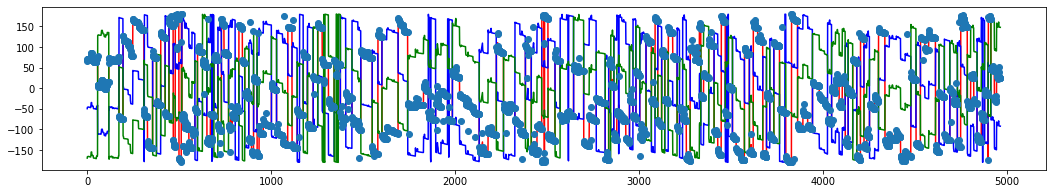

In [11]:
ax = plt.figure(figsize = (18,3))
ax = plt.plot(df["R1-PA1:VH"],'r')
ax = plt.plot(df["R1-PA2:VH"],'b')
ax = plt.plot(df["R1-PA3:VH"],'g')
ax = plt.plot(df["R1-PA4:IH"],'o');

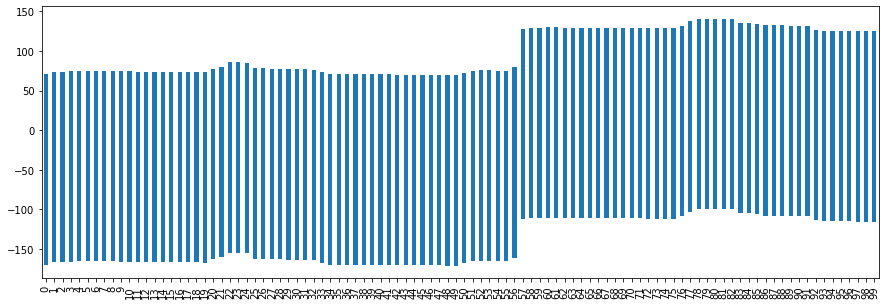

In [12]:
df["R1-PA1:VH"][:100].plot(kind="bar",figsize=(15,5))
df["R1-PA2:VH"][:100].plot(kind="bar",figsize=(15,5))
df["R1-PA3:VH"][:100].plot(kind="bar",figsize=(15,5))
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['marker'] = encoder.fit_transform(df['marker'])
df.head()

,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH,R1-PM3:V,R1-PA4:IH,R1-PM4:I,R1-PA5:IH,R1-PM5:I,R1-PA6:IH,R1-PM6:I,R1-PA7:VH,R1-PM7:V,R1-PA8:VH,R1-PM8:V,R1-PA9:VH,R1-PM9:V,R1-PA10:IH,R1-PM10:I,R1-PA11:IH,R1-PM11:I,R1-PA12:IH,R1-PM12:I,R1:F,R1:DF,R1-PA:Z,R1-PA:ZH,R1:S,R2-PA1:VH,R2-PM1:V,R2-PA2:VH,R2-PM2:V,R2-PA3:VH,R2-PM3:V,R2-PA4:IH,R2-PM4:I,R2-PA5:IH,R2-PM5:I,R2-PA6:IH,R2-PM6:I,R2-PA7:VH,R2-PM7:V,R2-PA8:VH,R2-PM8:V,R2-PA9:VH,R2-PM9:V,R2-PA10:IH,R2-PM10:I,R2-PA11:IH,R2-PM11:I,R2-PA12:IH,R2-PM12:I,R2:F,R2:DF,R2-PA:Z,R2-PA:ZH,R2:S,R3-PA1:VH,R3-PM1:V,R3-PA2:VH,R3-PM2:V,R3-PA3:VH,R3-PM3:V,R3-PA4:IH,R3-PM4:I,R3-PA5:IH,R3-PM5:I,R3-PA6:IH,R3-PM6:I,R3-PA7:VH,R3-PM7:V,R3-PA8:VH,R3-PM8:V,R3-PA9:VH,R3-PM9:V,R3-PA10:IH,R3-PM10:I,R3-PA11:IH,R3-PM11:I,R3-PA12:IH,R3-PM12:I,R3:F,R3:DF,R3-PA:Z,R3-PA:ZH,R3:S,R4-PA1:VH,R4-PM1:V,R4-PA2:VH,R4-PM2:V,R4-PA3:VH,R4-PM3:V,R4-PA4:IH,R4-PM4:I,R4-PA5:IH,R4-PM5:I,R4-PA6:IH,R4-PM6:I,R4-PA7:VH,R4-PM7:V,R4-PA8:VH,R4-PM8:V,R4-PA9:VH,R4-PM9:V,R4-PA10:IH,R4-PM10:I,R4-PA11:IH,R4-PM11:I,R4-PA12:IH,R4-PM12:I,R4:F,R4:DF,R4-PA:Z,R4-PA:ZH,R4:S,control_panel_log1,control_panel_log2,control_panel_log3,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4,marker
0,70.399324,127673.0908,-49.572308,127648.0176,-169.578319,127723.2374,65.689611,605.91099,-57.003571,626.78553,-173.589023,602.43190,70.422243,127673.0908,0.0,0.0,0.0,0.0,65.007791,611.58740,118.567886,13.18392,-100.869220,13.91636,59.999,0.01,6.391383,0.076290,0,60.658268,124631.8125,-59.295959,124484.3594,-179.338078,124715.0703,-119.550481,612.796753,117.726753,632.532104,0.859680,610.141724,60.680241,124611.9844,0.0,0.0,0.0,0.0,-120.341499,618.301392,-64.053043,12.765884,69.397891,12.828827,59.999001,0.02,6.130100,3.135101,0,60.664771,124187.9063,-59.312591,124162.8330,-179.301412,124212.9796,-119.753909,610.12252,117.685531,628.25041,0.658901,606.82654,60.687690,124187.9063,0.0,0.0,0.0,0.0,-120.487295,614.88338,-64.812986,12.08526,70.387865,11.90215,59.999,0.02,6.111440,3.140520,0,70.450890,127723.2374,-49.537931,127096.4056,-169.532482,127773.3839,65.643775,604.44611,-56.871791,621.84156,-173.869773,599.86836,70.462350,127522.6512,0.0,0.0,0.0,0.0,64.950496,608.47453,119.301272,12.26837,-102.060972,11.71904,59.999,0.01,6.341832,0.077897,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,73.688102,130280.7109,-46.300719,130255.6377,-166.278082,130355.9307,71.831719,483.59351,-50.947407,500.98896,-167.487023,481.39619,73.705291,130305.7842,0.0,0.0,0.0,0.0,71.109792,488.35437,125.792884,10.62038,-95.884487,11.35282,60.005,0.00,8.185463,0.024924,0,66.069035,128277.4297,-53.885193,128126.3047,-173.932803,128354.7578,-114.925241,489.349365,122.148740,505.754456,5.468445,487.335205,66.085509,128251.6250,0.0,0.0,0.0,0.0,-115.787662,493.978516,-59.669496,10.797501,72.424621,10.808945,60.005001,0.00,7.924891,-3.136669,0,66.062034,127823.5305,-53.909599,127798.4572,-173.892691,127848.6037,-115.124410,487.07260,122.125954,502.08762,5.259753,484.32595,66.090682,127823.5305,0.0,0.0,0.0,0.0,-115.932280,491.10102,-60.172028,10.25416,73.533403,10.07105,60.005,0.00,7.898427,-3.131062,0,73.745398,130330.8575,-46.249153,129704.0257,-166.232245,130381.0040,71.837448,481.76241,-50.792709,496.04499,-167.618803,477.73399,73.756857,130130.2713,0.0,0.0,0.0,0.0,71.121251,485.05839,124.274546,10.25416,-95.454769,9.70483,60.005,0.00,8.141328,0.027210,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,73.733939,130305.7842,-46.254883,130280.7109,-166.232245,130381.0040,71.808800,483.59351,-50.913030,500.98896,-167.441186,481.02997,73.751127,130330.8575,0.0,0.0,0.0,0.0,71.132710,488.35437,125.007932,10.62038,-94.520847,11.35282,60.005,0.00,8.190006,0.027904,0,66.112980,128283.9453,-53.852234,128144.4688,-173.883366,128382.9609,-114.919736,488.885864,122.214665,505.531311,5.462952,487.627014,66.129454,128269.5938,0.0,0.0,0.0,0.0,-115.765696,493.852600,-58.653259,10.396957,72.177430,10.768890,60.005001,0.00,7.931677,-3.136360,0,66.119330,127823.5305,-53.863762,127798.4572,-173.8

In [14]:
X = df.drop('marker',axis=1)
y = df['marker']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=21)

<font color="#936747" size=+2.5><b>Extra Trees Classifier</b></font>

 Train set score: 1.00
 Accuracy Score : 0.98
 Precision Score: 0.96
 Recall Score   : 0.94
 f1 Score       : 0.95 

 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       726
           1       0.96      0.94      0.95       198

    accuracy                           0.98       924
   macro avg       0.97      0.96      0.97       924
weighted avg       0.98      0.98      0.98       924
 

 Confusion Matrix:
 [[719   7]
 [ 12 186]]


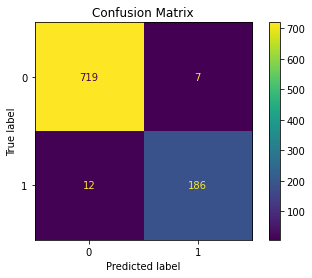

In [15]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,plot_confusion_matrix
# Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier
ExtraTreesClassifier = ExtraTreesClassifier()
ExtraTreesClassifier.fit(X_train, y_train)
y_pred_ExtraTreesClassifier = ExtraTreesClassifier.predict(X_test)
acc_ExtraTreesClassifier = round(accuracy_score(y_test,y_pred_ExtraTreesClassifier)*100,2)

print(f"\033[031m\033[1m","Train set score: {:.2f}".format(ExtraTreesClassifier.score(X_train, y_train)))
print(f"\033[031m\033[1m","Accuracy Score : {:.2f}".format(accuracy_score(y_test,y_pred_ExtraTreesClassifier)))
print(f"\033[031m\033[1m","Precision Score: {:.2f}".format(precision_score(y_test,y_pred_ExtraTreesClassifier)))
print(f"\033[031m\033[1m","Recall Score   : {:.2f}".format(recall_score(y_test,y_pred_ExtraTreesClassifier)))
print(f"\033[031m\033[1m","f1 Score       : {:.2f}".format(f1_score(y_test,y_pred_ExtraTreesClassifier)),'\n')
print(f"\033[032m\033[1m","Classification Report:\n", classification_report(y_test,y_pred_ExtraTreesClassifier),'\n')
print(f"\033[034m\033[1m","Confusion Matrix:\n",confusion_matrix(y_test,y_pred_ExtraTreesClassifier))
plot_confusion_matrix(ExtraTreesClassifier, X_test, y_test);
plt.title('Confusion Matrix');

<font color="lightseagreen" size=+2.5><b>XGBClassifier</b></font>

 Train set score: 1.00
 Accuracy Score : 0.97
 Precision Score: 0.95
 Recall Score   : 0.89
 f1 Score       : 0.92 

 Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       726
           1       0.95      0.89      0.92       198

    accuracy                           0.97       924
   macro avg       0.96      0.94      0.95       924
weighted avg       0.97      0.97      0.97       924
 

 Confusion Matrix:
 [[717   9]
 [ 22 176]]


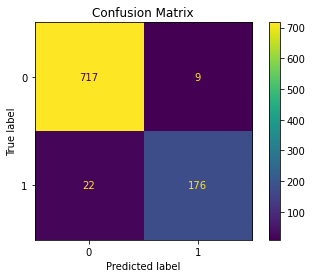

In [16]:
# XGBClassifier
from xgboost import XGBClassifier

XGBClassifier = XGBClassifier()
XGBClassifier.fit(X_train, y_train)
y_pred_XGBClassifier = XGBClassifier.predict(X_test)
acc_XGBClassifier = round(accuracy_score(y_test,y_pred_XGBClassifier)*100,2)

print(f"\033[031m\033[1m","Train set score: {:.2f}".format(XGBClassifier.score(X_train, y_train)))
print(f"\033[031m\033[1m","Accuracy Score : {:.2f}".format(accuracy_score(y_test,y_pred_XGBClassifier)))
print(f"\033[031m\033[1m","Precision Score: {:.2f}".format(precision_score(y_test,y_pred_XGBClassifier)))
print(f"\033[031m\033[1m","Recall Score   : {:.2f}".format(recall_score(y_test,y_pred_XGBClassifier)))
print(f"\033[031m\033[1m","f1 Score       : {:.2f}".format(f1_score(y_test,y_pred_XGBClassifier)),'\n')
print(f"\033[032m\033[1m","Classification Report:\n", classification_report(y_test,y_pred_XGBClassifier),'\n')
print(f"\033[034m\033[1m","Confusion Matrix:\n",confusion_matrix(y_test,y_pred_XGBClassifier))
plot_confusion_matrix(XGBClassifier, X_test, y_test);
plt.title('Confusion Matrix');

<font color="lightseagreen" size=+2.5><b>Random Forest Classifier</b></font>

 Train set score: 1.00
 Accuracy Score : 0.97
 Precision Score: 0.96
 Recall Score   : 0.90
 f1 Score       : 0.93 

 Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       726
           1       0.96      0.90      0.93       198

    accuracy                           0.97       924
   macro avg       0.97      0.95      0.96       924
weighted avg       0.97      0.97      0.97       924
 

 Confusion Matrix:
 [[718   8]
 [ 19 179]]


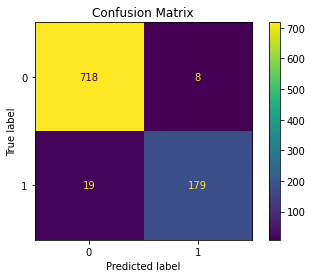

In [17]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
RandomForestClassifier = RandomForestClassifier(n_estimators=100)
RandomForestClassifier.fit(X_train, y_train)
y_pred_RandomForestClassifier = RandomForestClassifier.predict(X_test)
acc_RandomForestClassifier = round(accuracy_score(y_test,y_pred_RandomForestClassifier)*100,2)

print(f"\033[031m\033[1m","Train set score: {:.2f}".format(RandomForestClassifier.score(X_train, y_train)))
print(f"\033[031m\033[1m","Accuracy Score : {:.2f}".format(accuracy_score(y_test,y_pred_RandomForestClassifier)))
print(f"\033[031m\033[1m","Precision Score: {:.2f}".format(precision_score(y_test,y_pred_RandomForestClassifier)))
print(f"\033[031m\033[1m","Recall Score   : {:.2f}".format(recall_score(y_test,y_pred_RandomForestClassifier)))
print(f"\033[031m\033[1m","f1 Score       : {:.2f}".format(f1_score(y_test,y_pred_RandomForestClassifier)),'\n')
print(f"\033[032m\033[1m","Classification Report:\n", classification_report(y_test,y_pred_RandomForestClassifier),'\n')
print(f"\033[034m\033[1m","Confusion Matrix:\n",confusion_matrix(y_test,y_pred_RandomForestClassifier))
plot_confusion_matrix(RandomForestClassifier, X_test, y_test);
plt.title('Confusion Matrix');

<font color="lightseagreen" size=+2.5><b>BaggingClassifier</b></font>

 Train set score: 1.00
 Accuracy Score : 0.95
 Precision Score: 0.92
 Recall Score   : 0.85
 f1 Score       : 0.89 

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       726
           1       0.92      0.85      0.89       198

    accuracy                           0.95       924
   macro avg       0.94      0.92      0.93       924
weighted avg       0.95      0.95      0.95       924
 

 Confusion Matrix:
 [[712  14]
 [ 29 169]]


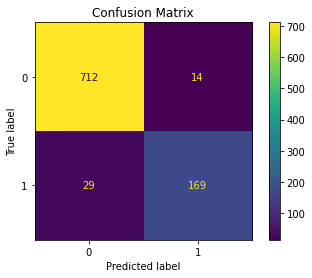

In [18]:
# BaggingClassifier
from sklearn.ensemble import BaggingClassifier
BaggingClassifier = BaggingClassifier()
BaggingClassifier.fit(X_train, y_train)
y_pred_BaggingClassifier = BaggingClassifier.predict(X_test)
acc_BaggingClassifier = round(accuracy_score(y_test,y_pred_BaggingClassifier)*100,2)

print(f"\033[031m\033[1m","Train set score: {:.2f}".format(BaggingClassifier.score(X_train, y_train)))
print(f"\033[031m\033[1m","Accuracy Score : {:.2f}".format(accuracy_score(y_test,y_pred_BaggingClassifier)))
print(f"\033[031m\033[1m","Precision Score: {:.2f}".format(precision_score(y_test,y_pred_BaggingClassifier)))
print(f"\033[031m\033[1m","Recall Score   : {:.2f}".format(recall_score(y_test,y_pred_BaggingClassifier)))
print(f"\033[031m\033[1m","f1 Score       : {:.2f}".format(f1_score(y_test,y_pred_BaggingClassifier)),'\n')
print(f"\033[032m\033[1m","Classification Report:\n", classification_report(y_test,y_pred_BaggingClassifier),'\n')
print(f"\033[034m\033[1m","Confusion Matrix:\n",confusion_matrix(y_test,y_pred_BaggingClassifier))
plot_confusion_matrix(BaggingClassifier, X_test, y_test);
plt.title('Confusion Matrix');

<font color="lightseagreen" size=+2.5><b>LogisticRegressionClassifier</b></font>

 Train set score: 0.77
 Accuracy Score : 0.77
 Precision Score: 0.38
 Recall Score   : 0.15
 f1 Score       : 0.21 

 Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.94      0.86       726
           1       0.38      0.15      0.21       198

    accuracy                           0.77       924
   macro avg       0.59      0.54      0.54       924
weighted avg       0.71      0.77      0.72       924
 

 Confusion Matrix:
 [[679  47]
 [169  29]]


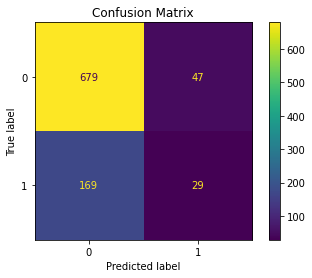

In [19]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression

LogisticRegression = LogisticRegression()
LogisticRegression.fit(X_train, y_train)
y_pred_LogisticRegression = LogisticRegression.predict(X_test)
acc_LogisticRegression = round(accuracy_score(y_test,y_pred_LogisticRegression)*100,2)

print(f"\033[031m\033[1m","Train set score: {:.2f}".format(LogisticRegression.score(X_train, y_train)))
print(f"\033[031m\033[1m","Accuracy Score : {:.2f}".format(accuracy_score(y_test,y_pred_LogisticRegression)))
print(f"\033[031m\033[1m","Precision Score: {:.2f}".format(precision_score(y_test,y_pred_LogisticRegression)))
print(f"\033[031m\033[1m","Recall Score   : {:.2f}".format(recall_score(y_test,y_pred_LogisticRegression)))
print(f"\033[031m\033[1m","f1 Score       : {:.2f}".format(f1_score(y_test,y_pred_LogisticRegression)),'\n')
print(f"\033[032m\033[1m","Classification Report:\n", classification_report(y_test,y_pred_LogisticRegression),'\n')
print(f"\033[034m\033[1m","Confusion Matrix:\n",confusion_matrix(y_test,y_pred_LogisticRegression))
plot_confusion_matrix(LogisticRegression, X_test, y_test);
plt.title('Confusion Matrix');

## DecisionTree

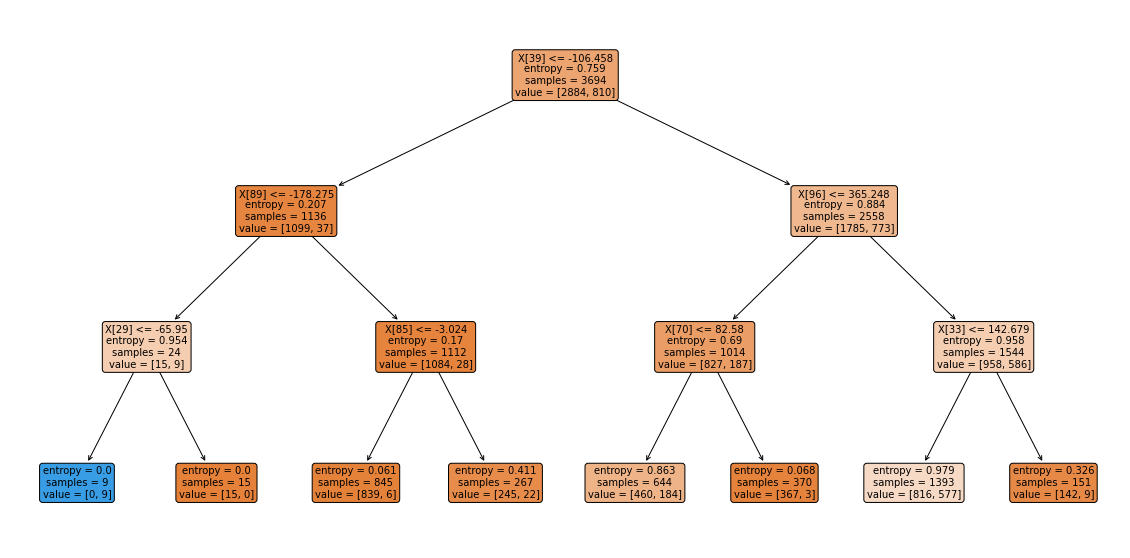

In [20]:
from six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import graphviz
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'Lucida Calligraphy'  
plt.rcParams['axes.facecolor'] = 'Black'
plt.rcParams["axes.labelcolor"] = 'Red'
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree classifer object
dec = DecisionTreeClassifier(criterion="entropy",max_depth=3)
dec.fit(X_train,y_train)
dec = dec.fit(X_train,y_train)

fig, ax = plt.subplots(figsize=(20, 10))
tree.plot_tree(dec, fontsize=10, filled=True, rounded=True)
plt.show()


## Voting Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

rnd_clf = RandomForestClassifier(n_estimators=100,random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100,random_state=42)
svm_clf = SVC(max_iter=100,tol=20,random_state=42)
mlp_clf = MLPClassifier(random_state=42)

estimators = [rnd_clf,extra_trees_clf,svm_clf,mlp_clf]
for estimator in estimators:
    print("Training the", estimator)
    estimator.fit(X_train,y_train)

Training the RandomForestClassifier(random_state=42)
Training the ExtraTreesClassifier(random_state=42)
Training the SVC(max_iter=100, random_state=42, tol=20)
Training the MLPClassifier(random_state=42)


In [22]:
from sklearn.ensemble import VotingClassifier

named_estimators = [
    ("random_forest_clf",rnd_clf),
    ("Extra_trees_clf",extra_trees_clf),
    ("SVM",svm_clf),
    ("MLP",mlp_clf)
]

voting_clf = VotingClassifier(named_estimators)

print(voting_clf.fit(X_train,y_train))
print("voting_clf.score:",voting_clf.score(X_test,y_test))

VotingClassifier(estimators=[('random_forest_clf',
                              RandomForestClassifier(random_state=42)),
                             ('Extra_trees_clf',
                              ExtraTreesClassifier(random_state=42)),
                             ('SVM',
                              SVC(max_iter=100, random_state=42, tol=20)),
                             ('MLP', MLPClassifier(random_state=42))])
voting_clf.score: 0.9772727272727273


## Roc Auc Curve

In [23]:
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import log_loss

def cross_val(X, y, model, params, folds=9,lw=5):

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=21)
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"Fold: {fold}")
        x_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        x_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        alg = model(**params)
        alg.fit(x_train, y_train,
                eval_set=[(x_test, y_test)],
                early_stopping_rounds=100,
                verbose=400,
                eval_metric='mlogloss')

        pred = alg.predict_proba(x_test)
        loss = log_loss(y_test, pred)
        print(f"Log loss: {loss}")
        print("-"*50)
    
    return alg

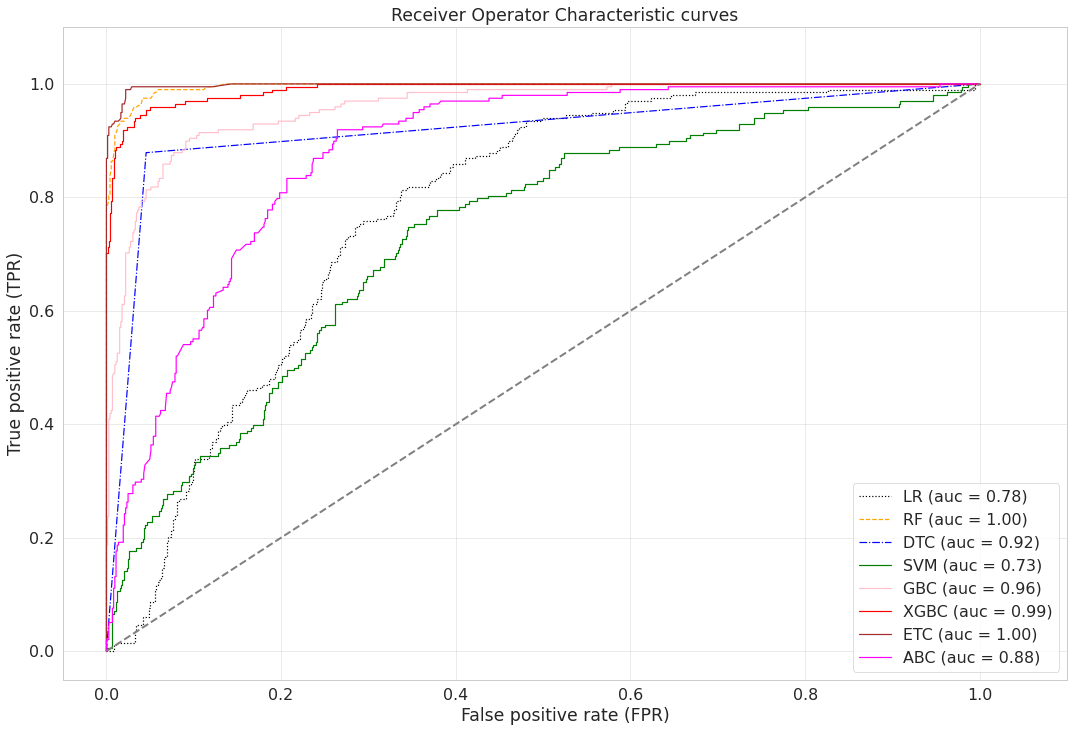

In [24]:
plt.figure(figsize=(18,12))
sns.set_theme(style="whitegrid")
sns.set_context('paper', font_scale=1.8)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

lr = LogisticRegression()
rf = RandomForestClassifier()
abc = AdaBoostClassifier()
gbc = GradientBoostingClassifier()
bc = BaggingClassifier()
etc = ExtraTreesClassifier()
xgbc = XGBClassifier()
svm = SVC(probability=True)
dtc = DecisionTreeClassifier()

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


all_clf=[lr, rf,dtc,svm,gbc,xgbc,etc,abc]
clf_labels=["LR", "RF","DTC", "SVM","GBC","XGBC","ETC","ABC"]
colors =["black", "orange", "blue", "green","pink","red","Brown","Magenta"]
linestyles = [":","--", "-.","-","-","-","-","-"]

for clf, label,clr,ls in zip(all_clf, clf_labels, colors, linestyles):
  y_pred= clf.fit(X_train,y_train).predict_proba(X_test)[:,1]
  fpr,tpr,thresholds = roc_curve(y_true= y_test, y_score=y_pred)
  roc_auc= auc(x=fpr, y=tpr)
  plt.plot(fpr, tpr, color=clr, linestyle=ls,
           label='%s (auc = %0.2f)' % (label, roc_auc))
  
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],linestyle='--',color='gray',linewidth=2)
plt.xlim([-0.05,1.1])
plt.ylim([-0.05,1.1])
plt.grid(alpha=0.5)
plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')
plt.title('Receiver Operator Characteristic curves')
plt.show()

## Grid Search CV

### DecisionTreeClassifier

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold,StratifiedShuffleSplit

# Create the parameter grid based on the results of random search 
params = {
    'max_depth': [5, 10, 20,25],
    'min_samples_leaf': [10, 20, 50, 100,120],
    'criterion': ["gini", "entropy"]
}

cv = StratifiedShuffleSplit(n_splits = 10, test_size = .25)

grid_dec = GridSearchCV(estimator=DecisionTreeClassifier(), 
                           param_grid=params, 
                           cv=cv, n_jobs=-1, verbose=1, scoring = "accuracy")

grid_dec.fit(X_train,y_train)

Fitting 10 folds for each of 40 candidates, totalling 400 fits


GridSearchCV(cv=StratifiedShuffleSplit(n_splits=10, random_state=None, test_size=0.25,
            train_size=None),
             estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, 25],
                         'min_samples_leaf': [10, 20, 50, 100, 120]},
             scoring='accuracy', verbose=1)

In [26]:
print (grid_dec.best_score_)
print (grid_dec.best_params_)
print(grid_dec.best_estimator_)

0.8969696969696969
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 10}
DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=10)


In [27]:
decision_accuracy_grid = grid_dec.best_score_.round(5)
decision_accuracy_grid

0.89697